In [ ]:
from google.colab import drive
drive.mount( '/content/drive')

Mounted at /content/drive


In [ ]:
import gdown
import os
import zipfile
import shutil
from pathlib import Path

drive_url = "https://drive.google.com/file/d/1MnrmdoB8G-U2-8n2jkQ3S3Jt5Vh78VeJ/view?usp=sharing"
zip_path = "/content/onion_leaf_dataset.zip"
extract_path = "/content/onion_leaf_dataset"


gdown.download(drive_url, zip_path, quiet=False, fuzzy=True)

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted.")
print(os.listdir(extract_path))


Downloading...
From (original): https://drive.google.com/uc?id=1MnrmdoB8G-U2-8n2jkQ3S3Jt5Vh78VeJ
From (redirected): https://drive.google.com/uc?id=1MnrmdoB8G-U2-8n2jkQ3S3Jt5Vh78VeJ&confirm=t&uuid=598384eb-e6d7-4efb-9b5a-96d3abdcda83
To: /content/onion_leaf_dataset.zip
100%|██████████| 501M/501M [00:06<00:00, 72.0MB/s]


Dataset extracted.
['onion_leaf']


In [ ]:

from pathlib import Path

raw_path = Path ("/content/onion_leaf_dataset")
def find_dataset_root(path):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    candidates = []
    for folder in path.rglob("*"):
        if folder.is_dir():
            subdirs = [d for d in folder.iterdir() if d.is_dir()]
            image_count = 0

            for subdir in subdirs:
                image_count += sum(
                    1 for f in subdir.iterdir()
                    if f.is_file() and f.suffix.lower() in image_extensions
                )

            if len(subdirs) >= 2 and image_count > 0:
                candidates.append(folder)

    if not candidates:
        raise ValueError("Could not find dataset root. Check ZIP folder structure.")

    return candidates[0]

dataset_root = find_dataset_root(raw_path)

print("Detected dataset root:", dataset_root)
print("Classes:")
for class_name in sorted(os.listdir(dataset_root)):
    print("-", class_name)

Detected dataset root: /content/onion_leaf_dataset/onion_leaf
Classes:
- Alternaria_D
- Botrytis Leaf Blight
- Bulb Rot
- Bulb_blight-D
- Caterpillar-P
- Downy mildew
- Fusarium-D
- Healthy leaves
- Iris yellow virus_augment
- Purple blotch
- Rust
- Virosis-D
- Xanthomonas Leaf Blight
- stemphylium Leaf Blight
- tip dieback and leaf blighting


In [ ]:
import random
from sklearn.model_selection import train_test_split
source_dir = Path(dataset_root)
split_dir = Path("/content/onion_leaf_dataset_split")

if split_dir.exists():
    shutil.rmtree(split_dir)

train_dir = split_dir / "train"
val_dir = split_dir / "val"
test_dir = split_dir / "test"

for folder in [train_dir, val_dir, test_dir]:
    folder.mkdir(parents=True, exist_ok=True)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

random.seed(42)

for class_folder in source_dir.iterdir():
    if not class_folder.is_dir():
        continue

    images = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]

    if len(images) == 0:
        continue

    train_files, temp_files = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    for split_name, files in [
        ("train", train_files),
        ("val", val_files),
        ("test", test_files)
    ]:
        target_class_dir = split_dir / split_name / class_folder.name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for file in files:
            shutil.copy2(file, target_class_dir / file.name)

print("Dataset split completed.")

for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}")
    split_path = split_dir / split_name
    total = 0

    for class_name in sorted(os.listdir(split_path)):
        count = len(os.listdir(split_path / class_name))
        total += count
        print(class_name, ":", count)

    print("Total:", total)



Dataset split completed.

TRAIN
Alternaria_D : 581
Botrytis Leaf Blight : 202
Bulb Rot : 4
Bulb_blight-D : 275
Caterpillar-P : 1090
Downy mildew : 25
Fusarium-D : 893
Healthy leaves : 2408
Iris yellow virus_augment : 1329
Purple blotch : 592
Rust : 149
Virosis-D : 358
Xanthomonas Leaf Blight : 132
stemphylium Leaf Blight : 1124
tip dieback and leaf blighting : 92
Total: 9254

VAL
Alternaria_D : 124
Botrytis Leaf Blight : 43
Bulb Rot : 1
Bulb_blight-D : 59
Caterpillar-P : 234
Downy mildew : 6
Fusarium-D : 191
Healthy leaves : 516
Iris yellow virus_augment : 285
Purple blotch : 127
Rust : 32
Virosis-D : 77
Xanthomonas Leaf Blight : 28
stemphylium Leaf Blight : 241
tip dieback and leaf blighting : 20
Total: 1984

TEST
Alternaria_D : 125
Botrytis Leaf Blight : 44
Bulb Rot : 2
Bulb_blight-D : 60
Caterpillar-P : 234
Downy mildew : 6
Fusarium-D : 192
Healthy leaves : 516
Iris yellow virus_augment : 285
Purple blotch : 128
Rust : 32
Virosis-D : 77
Xanthomonas Leaf Blight : 29
stemphylium Leaf 

In [ ]:
import tensorflow as tf

IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 9254 files belonging to 15 classes.
Found 1984 files belonging to 15 classes.
Found 1991 files belonging to 15 classes.
Class names: ['Alternaria_D', 'Botrytis Leaf Blight', 'Bulb Rot', 'Bulb_blight-D', 'Caterpillar-P', 'Downy mildew', 'Fusarium-D', 'Healthy leaves', 'Iris yellow virus_augment', 'Purple blotch', 'Rust', 'Virosis-D', 'Xanthomonas Leaf Blight', 'stemphylium Leaf Blight', 'tip dieback and leaf blighting']
Number of classes: 15


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [ ]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/tmp/ipykernel_1576/754672054.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/best_onion_leaf_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - accuracy: 0.3034 - loss: 2.0850 - val_accuracy: 0.5066 - val_loss: 1.4426
Epoch 2/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.5251 - loss: 1.3897 - val_accuracy: 0.6336 - val_loss: 1.0899
Epoch 3/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6062 - loss: 1.1394 - val_accuracy: 0.6815 - val_loss: 0.9300
Epoch 4/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6619 - loss: 0.9881 - val_accuracy: 0.7147 - val_loss: 0.8441
Epoch 5/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.6889 - loss: 0.9067 - val_accuracy: 0.7273 - val_loss: 0.7797
Epoch 6/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.7063 - loss: 0.8464 - val_accuracy: 0.7429 - val_loss: 0.7352
Epoch 7/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 28s 98ms/step - accuracy: 0.7203 - loss: 0.7984 - val_accuracy: 0.7495 - val_loss: 0.7028
Epoch 8/30
290/290 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.7355 - loss: 0.7578 -

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-45]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 51s 136ms/step - accuracy: 0.7294 - loss: 0.7942 - val_accuracy: 0.7747 - val_loss: 0.6585
Epoch 2/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 37s 129ms/step - accuracy: 0.7936 - loss: 0.5939 - val_accuracy: 0.7863 - val_loss: 0.6202
Epoch 3/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 37s 128ms/step - accuracy: 0.8246 - loss: 0.5133 - val_accuracy: 0.8014 - val_loss: 0.5671
Epoch 4/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.8401 - loss: 0.4657 - val_accuracy: 0.8175 - val_loss: 0.4930
Epoch 5/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 131ms/step - accuracy: 0.8555 - loss: 0.4229 - val_accuracy: 0.8327 - val_loss: 0.4453
Epoch 6/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 132ms/step - accuracy: 0.8630 - loss: 0.3939 - val_accuracy: 0.8483 - val_loss: 0.4112
Epoch 7/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 131ms/step - accuracy: 0.8780 - loss: 0.3561 - val_accuracy: 0.8654 - val_loss: 0.3730
Epoch 8/15
290/290 ━━━━━━━━━━━━━━━━━━━━ 38s 131ms/step - accuracy: 0.8828 - loss: 0

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9036 - loss: 0.2671
Test Loss: 0.2671103775501251
Test Accuracy: 0.9035660624504089


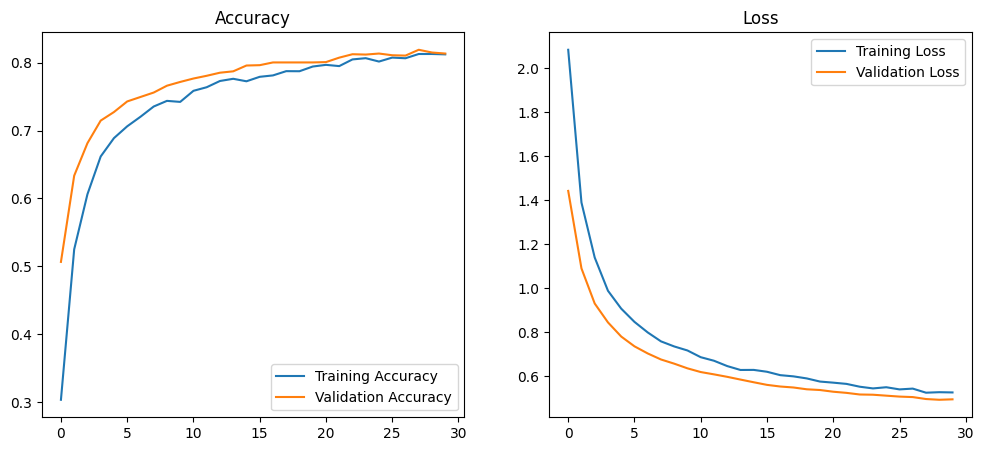

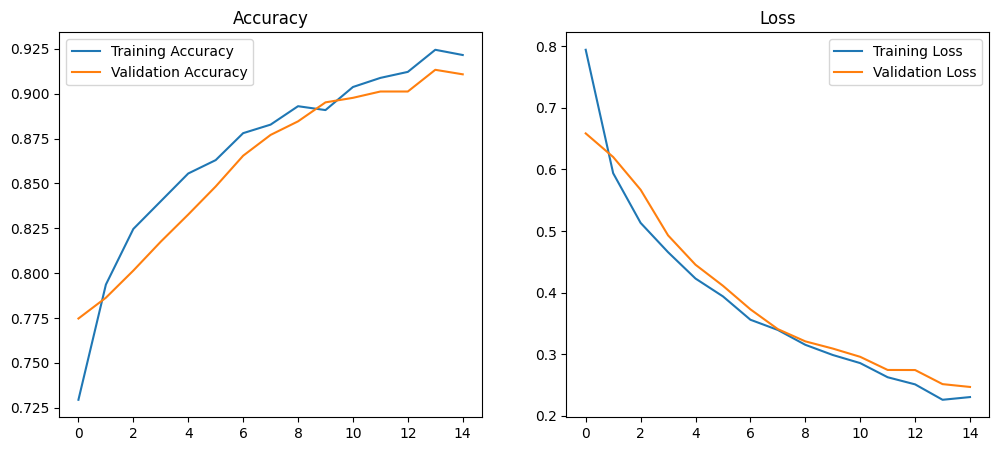

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history(history)
plot_history(fine_tune_history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

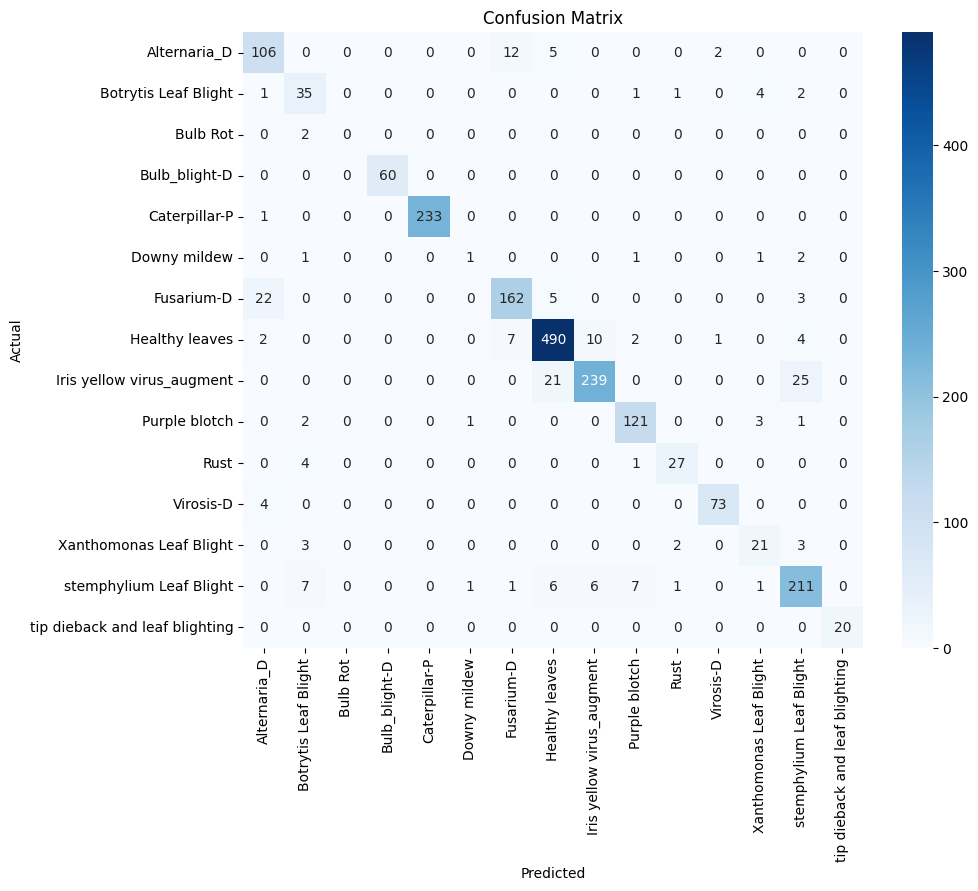

                                precision    recall  f1-score   support

                  Alternaria_D       0.78      0.85      0.81       125
          Botrytis Leaf Blight       0.65      0.80      0.71        44
                      Bulb Rot       0.00      0.00      0.00         2
                 Bulb_blight-D       1.00      1.00      1.00        60
                 Caterpillar-P       1.00      1.00      1.00       234
                  Downy mildew       0.33      0.17      0.22         6
                    Fusarium-D       0.89      0.84      0.87       192
                Healthy leaves       0.93      0.95      0.94       516
     Iris yellow virus_augment       0.94      0.84      0.89       285
                 Purple blotch       0.91      0.95      0.93       128
                          Rust       0.87      0.84      0.86        32
                     Virosis-D       0.96      0.95      0.95        77
       Xanthomonas Leaf Blight       0.70      0.72      0.71  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
import json

model.save("/content/onion_leaf_disease_mobilenetv2.keras")

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model saved at /content/onion_leaf_disease_mobilenetv2.keras")
print("Class names saved at /content/class_names.json")


Model saved at /content/onion_leaf_disease_mobilenetv2.keras
Class names saved at /content/class_names.json


In [ ]:
from google.colab import files

files.download("/content/onion_leaf_disease_mobilenetv2.keras")
files.download("/content/class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>